<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/2408947_RujanMaharjan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Unzipping the dataset

In [2]:
# No need to run this cell again as it unzips the dataset directly into the Google Drive, the unzipped files will persist across sessions and runtime changes.
# unless the dataset is deleted from the drive

# The place where the zip dataset is
zipped_file_path = '/content/drive/MyDrive/AI ML/Data/Pest Dataset.zip'

# The place where the dataset will be unziped
destination_path = '/content/drive/MyDrive/AI ML/Data'

# Unzip the file
!unzip "{zipped_file_path}" -d "{destination_path}"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_413.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_414.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_415.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_416.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_417.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_418.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Weevil/orig_419.jpg  
  inflating: /content/drive/MyDrive/AI ML/Data/working/dataset_publish/balanced_pest_dataset/train/Wee

# Part A: Designing and Analyzing Convolutional Neural Networks from Scratch

## Data Understanding, Analysis, Visualization and Cleaning:

### Understanding the Dataset

#### Checking total number of images in the dataset

In [5]:
import os

# The base path to the unzipped dataset
dataset_base_path = os.path.join(destination_path, 'working', 'dataset_publish', 'balanced_pest_dataset')

image_count = 0
# Define common image extensions to look for
image_extensions = ('.jpg', '.jpeg', '.png')

# Walk through the dataset directory
for root, _, files in os.walk(dataset_base_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_count += 1

print(f"Total number of images in the dataset: {image_count}")

Total number of images in the dataset: 34200


#### Checking the distribution of images across different classes

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the paths for train and validation datasets
train_path = os.path.join(dataset_base_path, 'train')
val_path = os.path.join(dataset_base_path, 'val')
test_path = os.path.join(dataset_base_path, 'test')

# Function to get class distribution
def get_class_distribution(base_dir):
    class_counts = {}
    for class_name in os.listdir(base_dir):
        class_dir = os.path.join(base_dir, class_name)
        if os.path.isdir(class_dir):
            count = len([f for f in os.listdir(class_dir) if f.lower().endswith(image_extensions)])
            class_counts[class_name] = count
    return class_counts

# Get distribution for train and validation sets
train_distribution = get_class_distribution(train_path)
val_distribution = get_class_distribution(val_path)
test_distribution = get_class_distribution(test_path)

# Convert to pandas Series for easier plotting
import pandas as pd
train_df = pd.Series(train_distribution, name='Count').reset_index()
train_df.columns = ['Class', 'Count']
train_df['Set'] = 'Train'

val_df = pd.Series(val_distribution, name='Count').reset_index()
val_df.columns = ['Class', 'Count']
val_df['Set'] = 'Validation'

test_df = pd.Series(test_distribution, name='Count').reset_index()
test_df.columns = ['Class', 'Count']
test_df['Set'] = 'Test'

# Combine for plotting
combined_df = pd.concat([train_df, val_df,test_df])

print("Training Set Distribution:")
print(train_df)
print("\nValidation Set Distribution:")
print(val_df)
print("\nTest Set Distribution:")
print(test_df)


Training Set Distribution:
                      Class  Count    Set
0             Adristyrannus   1500  Train
1                    Aphids   1500  Train
2                    Beetle   1500  Train
3                      Bugs   1500  Train
4            Cabbage Looper   1500  Train
5              Cicadellidae   1500  Train
6                   Cutworm   1500  Train
7                    Earwig   1500  Train
8              FieldCricket   1500  Train
9               Grasshopper   1500  Train
10  Mediterranean fruit fly   1500  Train
11                    Mites   1500  Train
12                RedSpider   1500  Train
13                Riptortus   1500  Train
14                     Slug   1500  Train
15                    Snail   1500  Train
16                   Thrips   1500  Train
17                   Weevil   1500  Train
18                 Whitefly   1500  Train

Validation Set Distribution:
                      Class  Count         Set
0             Adristyrannus    150  Validation
1        

#### Checking for Corrupted images in Dataset

In [14]:
from PIL import Image

def is_corrupted_image(image_path):
    """
    Checks if an image file is corrupted by attempting to open and verify it.
    Returns True if corrupted, False otherwise.
    """
    try:
        with Image.open(image_path) as img:
            img.verify()  # Verify integrity of the image file
        return False
    except Exception as e:
        print(f"Corrupted image detected: {image_path} - {e}")
        return True

In [15]:
print("Checking for corrupted images across Train, Validation, and Test sets")

corrupted_images_full_dataset = []

# List of paths to check
dataset_paths = {
    "Train": train_path,
    "Validation": val_path,
    "Test": test_path
}

for dataset_name, path in dataset_paths.items():
    print(f"\nChecking {dataset_name} set...")
    all_image_paths = []
    for class_name in class_names:
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            image_files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.lower().endswith(image_extensions)]
            all_image_paths.extend(image_files)

    print(f"Found {len(all_image_paths)} images in the {dataset_name} set to check.")
    for img_path in all_image_paths:
        if is_corrupted_image(img_path):
            corrupted_images_full_dataset.append(img_path)

if corrupted_images_full_dataset:
    print(f"\nFound {len(corrupted_images_full_dataset)} corrupted images in total across all datasets:")
    for c_img in corrupted_images_full_dataset:
        print(c_img)
else:
    print("\nNo corrupted images found in the entire dataset (Train, Validation, Test).")

Checking for corrupted images across Train, Validation, and Test sets

Checking Train set...
Found 28500 images in the Train set to check.

Checking Validation set...
Found 2850 images in the Validation set to check.

Checking Test set...
Found 2850 images in the Test set to check.

No corrupted images found in the entire dataset (Train, Validation, Test).


### Visualization

#### Visualizing the distribution of images accross different classes in train, test and val sets


##### Training set

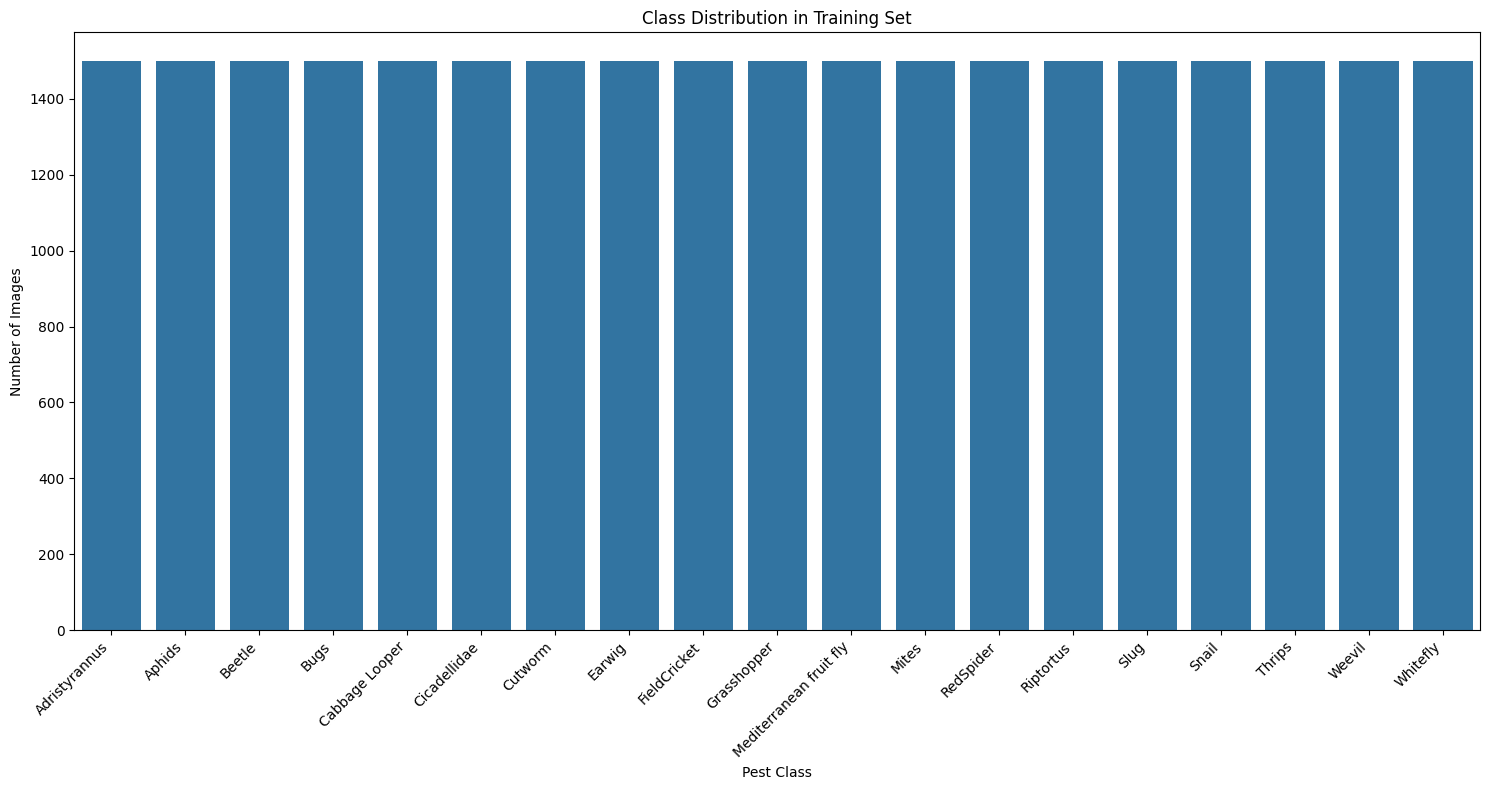

In [24]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=train_df)
plt.title('Class Distribution in Training Set')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Validation set

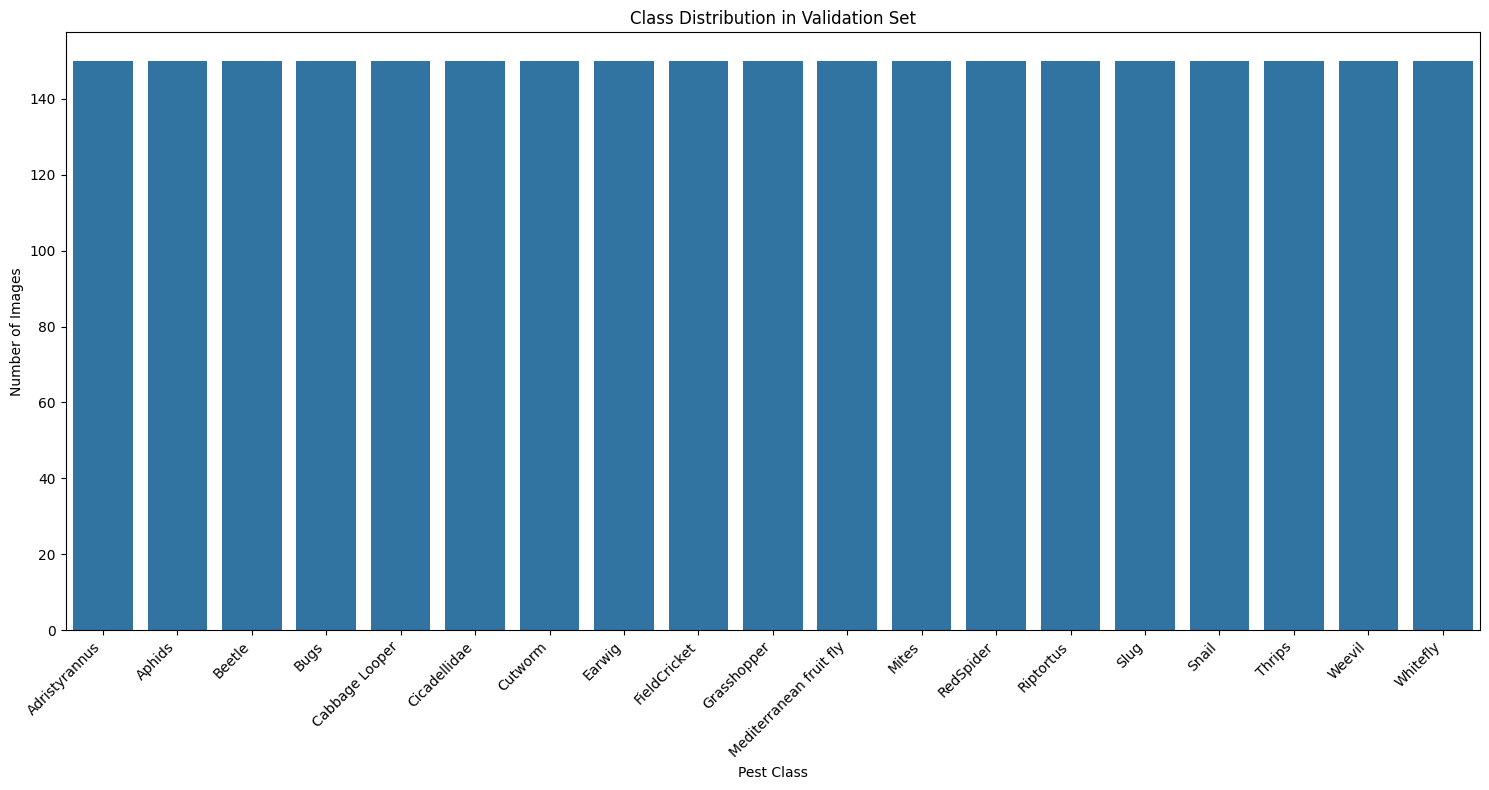

In [25]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=val_df)
plt.title('Class Distribution in Validation Set')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Test set

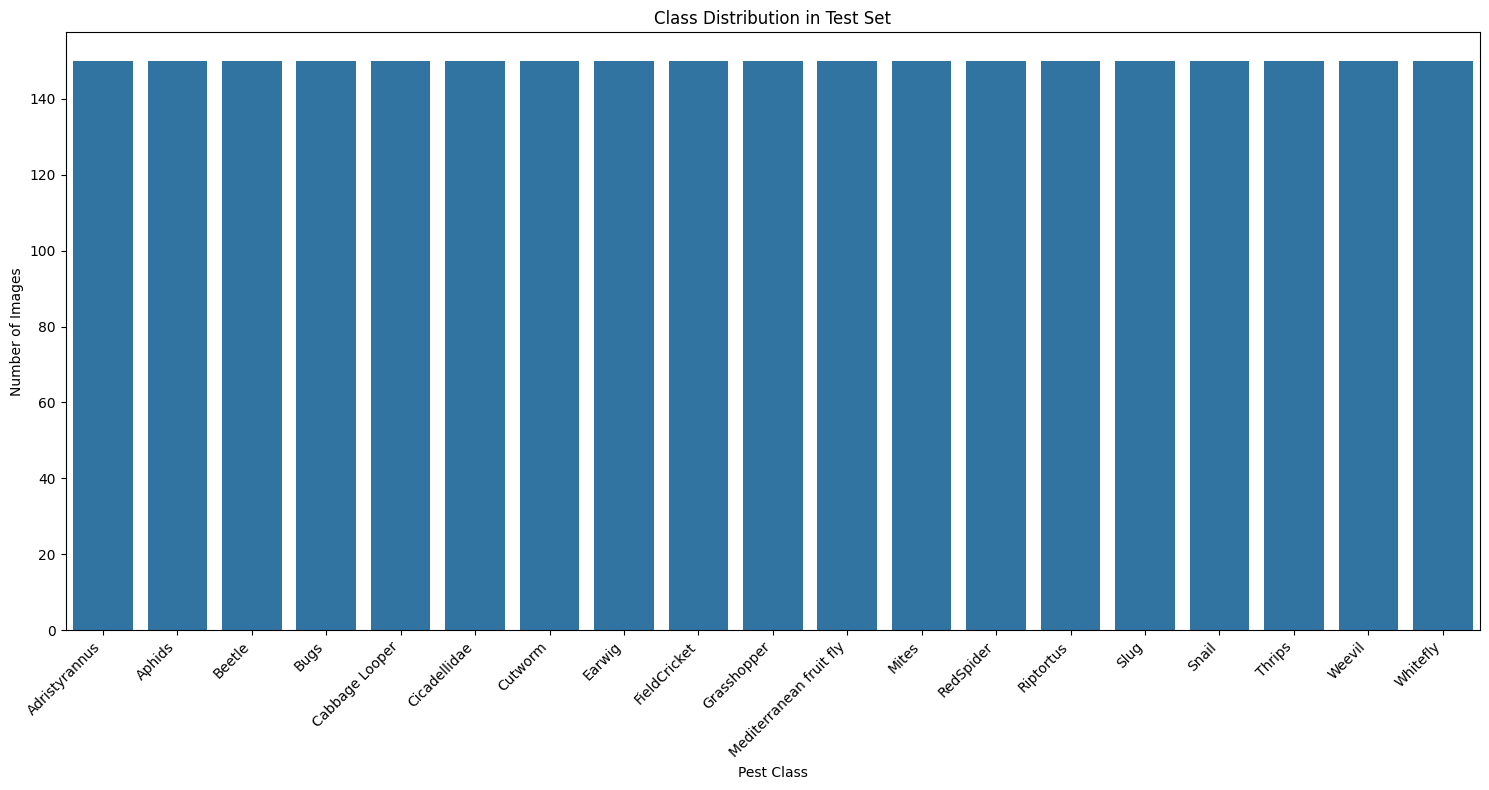

In [26]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', data=test_df)
plt.title('Class Distribution in Test Set')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Visualizing the distribution accross train, val and test sets

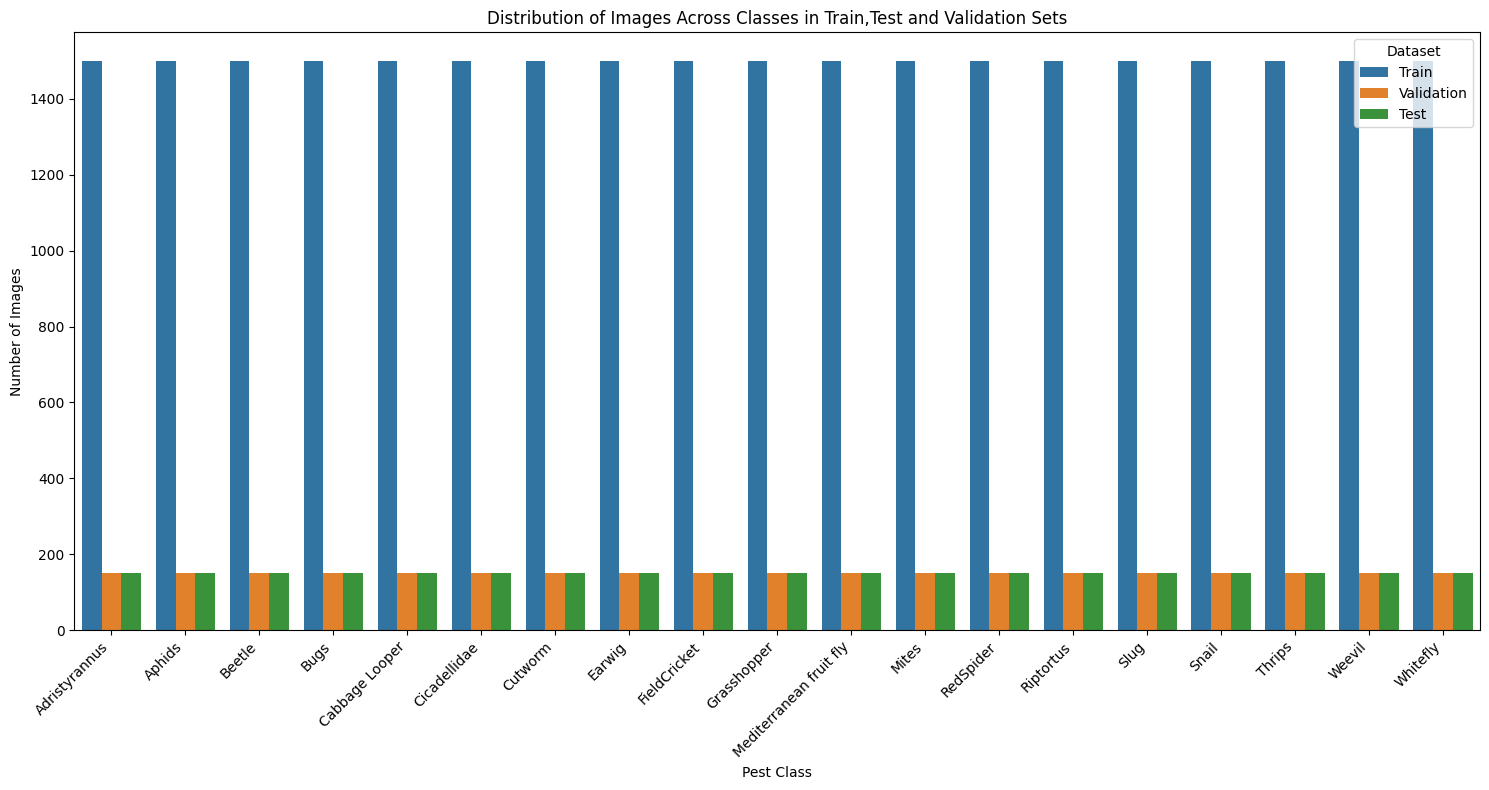

In [23]:
plt.figure(figsize=(15, 8))
sns.barplot(x='Class', y='Count', hue='Dataset', data=combined_df)
plt.title('Distribution of Images Across Classes in Train,Test and Validation Sets')
plt.xlabel('Pest Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The dataset is split into training and validation sets with a ratio of 10:1 for each class. Specifically, every class has 1500 images in the training set and 150 images in the validation set.
This type of split, where a larger portion of the data 91% for training set and 9% for validation set is a common practice in machine learning.

Justification :
* This split provides the model with enough data to
learn features and patterns effectively preventing underfittting.
* The validation set can be used to tune the hyperparameters and assess the model's performance unseen data without the risk of overfitting on the test set
* Since the 10:1 ratio is maintained for each class, this ensures that both the training and validation sets are class-balanced. This prevents bias to any major classes.

#### Visualizing augmented images.

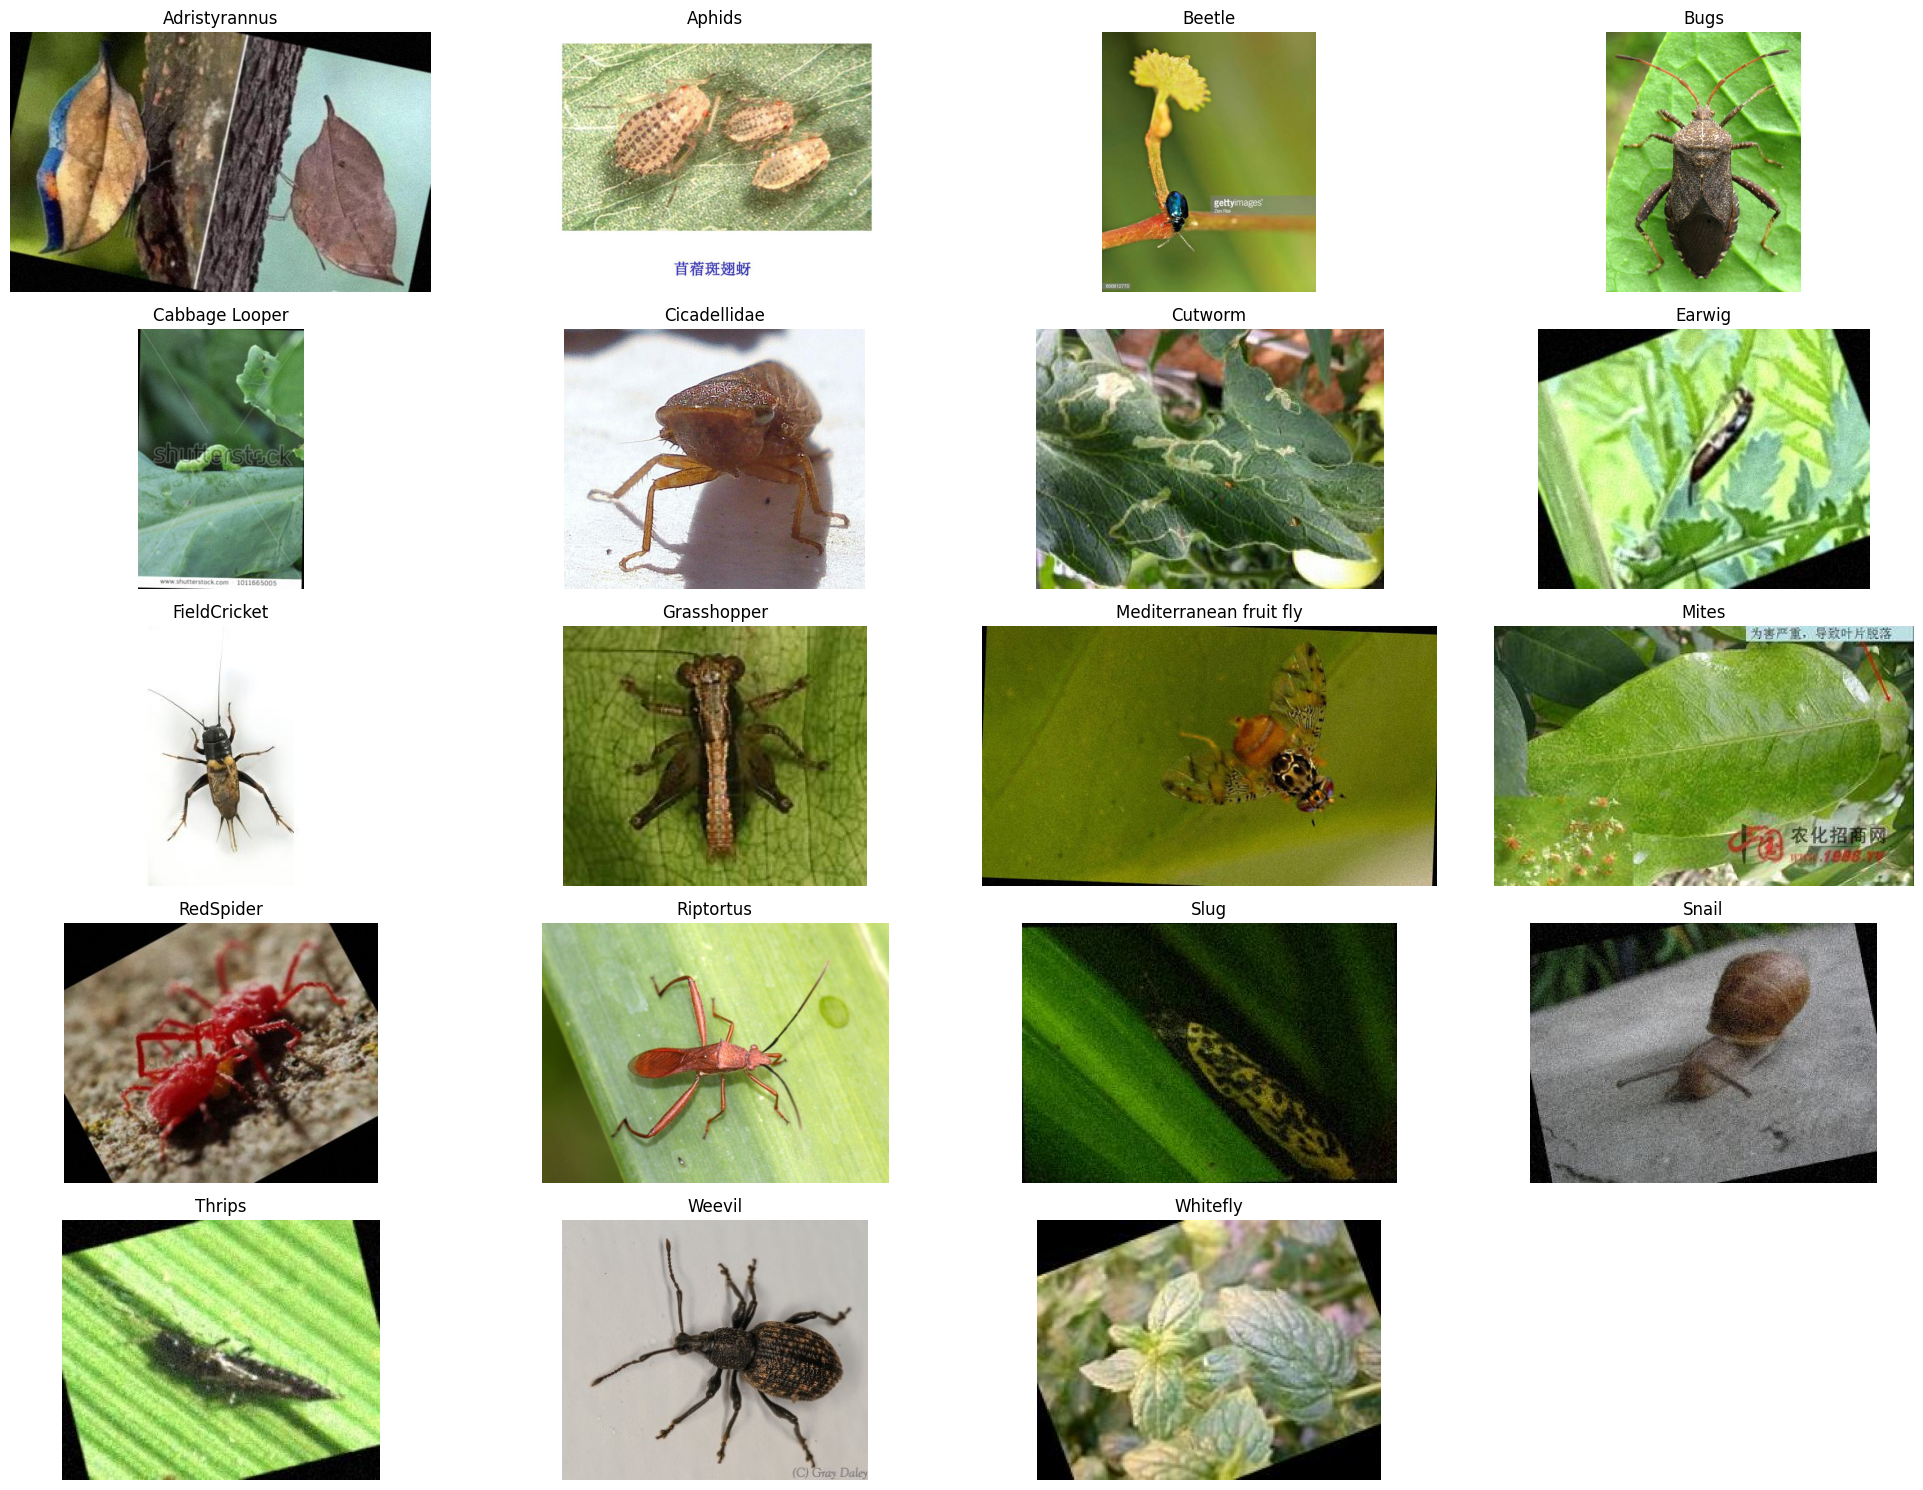

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Get the list of class names
class_names = sorted(os.listdir(train_path))

plt.figure(figsize=(20, 15))

# Loop through each class and display a sample image
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(train_path, class_name)
    if os.path.isdir(class_dir):
        # Get all image files in the class directory
        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(image_extensions)]
        if image_files:
            # Pick a random image from the class
            sample_image_name = random.choice(image_files)
            sample_image_path = os.path.join(class_dir, sample_image_name)

            # Load and display the image
            plt.subplot(5, 4, i + 1) # Adjust subplot grid based on number of classes
            img = mpimg.imread(sample_image_path)
            plt.imshow(img)
            plt.title(class_name, fontsize=12)
            plt.axis('off')

plt.tight_layout()
plt.show()

## Design, Train, and Evaluate a Baseline Model:

#### Model Architecture: